# Lab 1 · Làm quen Colab & quy trình làm việc với AI

**Lập trình xử lý dữ liệu (LTXLDL) · 2627-1 · Giờ thực hành · bài 1**

> 💡 File → **Save a copy in Drive** trước khi sửa.

Bài giảng đầu tiên đã giới thiệu tổng quan về môn học. Trong bài lab này, bạn sẽ sử dụng
Colab notebook, chạy một phân tích trên dữ liệu thật và thực hành đầy đủ
**quy trình 5 bước làm việc với AI**, bao gồm bước khai báo.

## Cách làm việc trong bài lab

- Bài tập được chia thành từng bước; mỗi bước có ô `TODO` và phần kiểm tra `assert`.
  Hoàn thành toàn bộ `assert` nghĩa là kết quả đáp ứng yêu cầu.
- Phần khởi động và bài có hướng dẫn: bạn nên **tự gõ, không dùng AI** — các bài kiểm tra
  định kỳ 🚫 đóng ở giờ lý thuyết đánh giá các kỹ năng này.
- Bài tự làm ở cuối được gắn nhãn ✅ mở: bạn được dùng AI, kèm trách nhiệm khai báo
  theo chính sách AI của môn.
- Nếu chưa giải quyết được một bước sau 3 phút, hãy hỏi giảng viên thực hành.

## Mục tiêu

Sau bài lab, bạn sẽ:

1. Sử dụng Colab để chạy và sửa cell, **Restart & Run all**, đồng thời lưu bản sao.
2. Giải thích được "trạng thái notebook": biến sống xuyên cell, thứ tự chạy quan trọng thế nào.
3. Chạy được một phân tích nhỏ trên dữ liệu Airbnb thật và đọc kết quả.
4. Thực hành đầy đủ quy trình 5 bước với AI: tự phác → hỏi → đọc hiểu → kiểm chứng → khai báo.

## Phần 0 · Khởi động (~10 phút)

Ba thao tác cần nắm trước khi bắt đầu các phần tiếp theo.

In [1]:
# W1 — chạy cell: bấm vào cell này rồi nhấn Shift+Enter
# TODO: điền tên của bạn vào chuỗi bên dưới rồi chạy
ten_cua_ban = "Lê Thảo Nguyên"

# --- Ô kiểm tra: không sửa phần dưới ---
assert len(ten_cua_ban) >= 2, "Bạn chưa điền tên vào biến ten_cua_ban"
print(f"Chào {ten_cua_ban}, notebook đã sẵn sàng.")

Chào Lê Thảo Nguyên, notebook đã sẵn sàng.


**W2 — ba thao tác menu cần nhớ** (làm ngay, mỗi thứ một lần):

1. **File → Save a copy in Drive** — nếu chưa làm ở đầu giờ.
2. **Runtime → Restart session** — khởi động lại "bộ nhớ" của notebook.
3. Sau khi restart: chạy lại ô W1 ở trên. Để ý: biến `ten_cua_ban` đã biến mất trước khi bạn
   chạy lại — restart xoá sạch trạng thái.

## Phần 1 · Trạng thái notebook — một nguồn lỗi thường gặp (~20 phút)

Notebook nhớ mọi biến bạn đã chạy — kể cả khi bạn đã sửa hoặc xoá cell tạo ra nó.
Ba thí nghiệm sau minh hoạ các lỗi thường gặp trong một môi trường an toàn.

### Bước 1 · Thứ tự chạy quan trọng

Hai ô dưới đây: hãy **chạy ô thứ hai trước** (ô có `print`). Bạn sẽ gặp `NameError` —
đọc thông báo lỗi, rồi chạy ô thứ nhất, rồi chạy lại ô thứ hai.

In [2]:
so_phong_gia_dinh = 4        # ô A — định nghĩa biến

In [3]:
# ô B — dùng biến (chạy ô này TRƯỚC ô A để xem NameError)
print("Số phòng:", so_phong_gia_dinh)

Số phòng: 4


`NameError: name '...' is not defined` cho biết biến chưa được định nghĩa trong phiên hiện tại.
Điều này thường xảy ra khi ô định nghĩa biến **chưa được chạy**, dù ô đó vẫn có trong file.
Đây là một lỗi thường gặp khi chạy notebook không theo thứ tự.

### Bước 2 · Cell chạy nhiều lần — giá trị cộng dồn

Ô dưới đây tăng `dem` lên 1. Hãy chạy nó **ba lần liên tiếp** và quan sát.

In [4]:
dem = 0                       # chạy ô này MỘT lần

In [5]:
dem = dem + 1                 # chạy ô này BA lần, xem số đổi thế nào
print("dem =", dem)

dem = 1


In [7]:
# TODO: dem đang bằng mấy sau 3 lần chạy? Điền dự đoán rồi chạy để kiểm tra
du_doan = 1

# --- Ô kiểm tra ---
assert du_doan == dem, f"dem thật sự là {dem}"
print("Đúng. Cell chạy lại là code chạy lại — notebook không tự 'reset'.")

Đúng. Cell chạy lại là code chạy lại — notebook không tự 'reset'.


### Bước 3 · Restart & Run all — kiểm tra trước khi nộp

**Restart session and run all.** Notebook cần chạy từ đầu đến cuối không lỗi trước khi nộp.
Sau khi chạy theo đúng thứ tự, ô B ở Bước 1 sẽ thực hiện thành công vì nằm *sau* ô A.

## Phần 2 · Phân tích đầu tiên trên dữ liệu thật (~20 phút)

Dữ liệu: 18.534 phòng Airbnb của Santiago (Chile).
Các ô dưới **viết sẵn để chạy và đọc** — chưa cần hiểu từng lệnh (bài 4 sẽ học kỹ);
việc của bạn là quan sát kết quả.

In [8]:
import pandas as pd

URL = ("https://data.insideairbnb.com/chile/rm/santiago/"
       "2026-06-29/visualisations/listings.csv")
ds = pd.read_csv(URL)

ds.shape                       # (số dòng, số cột)

(18534, 19)

In [15]:
ds[["name", "room_type", "price"]].head(3)

,name,room_type,price
0,luminosa mansarda con balcón,Private room,45647.0
1,Cómoda habitación bien ubicada con baño privado,Private room,19856.0
2,Cómodo departamento Cerca de Metro,Entire home/apt,46776.0


In [10]:
dem_loai = ds["room_type"].value_counts()
dem_loai

,count
room_type,
Entire home/apt,15004
Private room,3413
Shared room,61
Hotel room,56


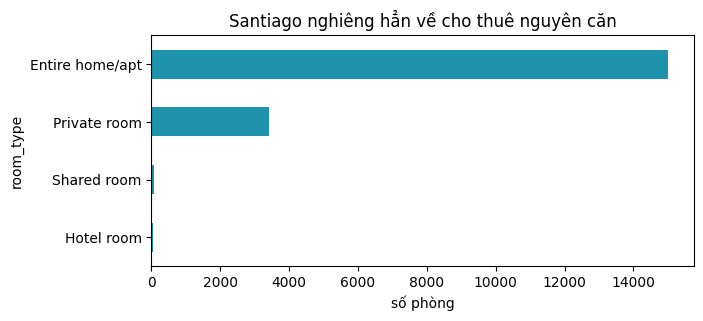

In [11]:
# Một biểu đồ đầu tiên — chỉ chạy và nhìn, code này bài 12 sẽ học kỹ
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3))
dem_loai.sort_values().plot.barh(ax=ax, color="#1E93AB")
ax.set_title("Santiago nghiêng hẳn về cho thuê nguyên căn")
ax.set_xlabel("số phòng")
plt.show()

In [14]:
# TODO: đọc kết quả các ô trên rồi điền hai con số
so_dong = 18534            # bảng có bao nhiêu dòng (xem ds.shape)
loai_nhieu_nhat = "Entire home/apt"    # chuỗi: tên loại phòng phổ biến nhất (xem dem_loai)

# --- Ô kiểm tra ---
assert so_dong == 18534
assert loai_nhieu_nhat == "Entire home/apt"
print(f"{so_dong:,} phòng; phổ biến nhất: {loai_nhieu_nhat}.")

18,534 phòng; phổ biến nhất: Entire home/apt.


## Phần 3 · Một vòng quy trình 5 bước với AI (~25 phút)

Nhiệm vụ: *"tính xem mỗi loại phòng chiếm bao nhiêu **phần trăm** thị trường Santiago"*.
Bạn sẽ nhờ AI viết code — nhưng theo đúng quy trình của môn.

### Bước 1 · Tự phác trước khi hỏi

Nhìn bảng `dem_loai` ở Phần 2: Entire home/apt là 15.004 trên 18.534 dòng — vậy nó phải
chiếm khoảng **80%**. Hãy dùng giá trị ước lượng này để kiểm chứng kết quả của AI.

### Bước 2–3 · Hỏi AI, rồi đọc hiểu

Mở một chatbot bất kỳ (Gemini, ChatGPT, Claude…) và hỏi, ví dụ:

> *Tôi có DataFrame pandas tên `ds` với cột `room_type`. Viết code tính phần trăm mỗi loại
> phòng, làm tròn 1 chữ số.*

Dán code AI trả về vào ô dưới. **Đọc từng dòng trước khi chạy**; nếu gặp hàm lạ, hãy
đối chiếu với tài liệu chính thức hoặc yêu cầu AI giải thích.

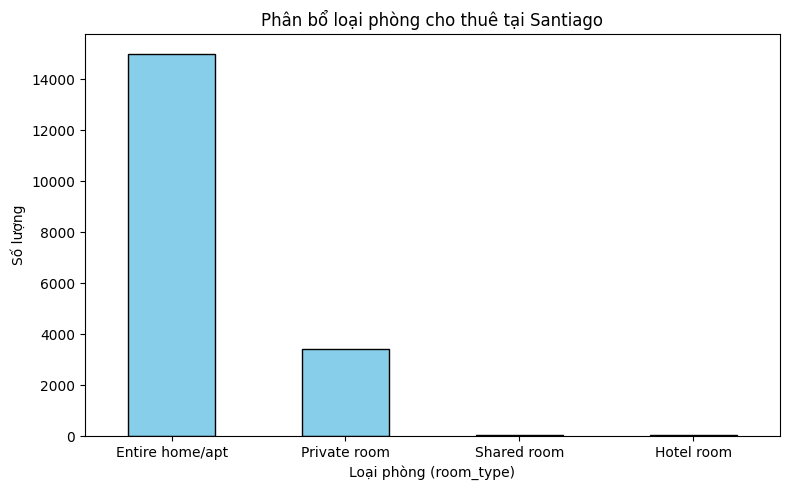

,proportion
room_type,
Entire home/apt,81.0
Private room,18.4
Shared room,0.3
Hotel room,0.3


In [24]:
# TODO: dán code AI đưa cho bạn vào đây, đọc hiểu rồi mới chạy.
# Yêu cầu: kết quả cuối là một Series tên ty_le (đơn vị %, làm tròn 1 chữ số)

#Bước 1: Thống kê số dòng và số cột của file
import pandas as pd

ds = pd.read_excel('listings_santiago.xlsx')

so_dong, so_cot = ds.shape

#Bước 2: Danh sách name, room_type và price của 3 phòng đầu tiên
danh_sach_3_dong = ds[['name', 'room_type', 'price']].head(3)

#Bước 3: Phân loại và đếm số lượng cho từng loại phòng
dem_room_type = ds['room_type'].value_counts()

#Bước 4: Vẽ biểu đồ phân bổ và nhận xét xu hướng
import matplotlib.pyplot as plt

# Dùng lại kết quả đếm ở Bước 3
dem_room_type = ds['room_type'].value_counts()

# Vẽ biểu đồ cột
plt.figure(figsize=(8, 5))
dem_room_type.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Phân bổ loại phòng cho thuê tại Santiago')
plt.xlabel('Loại phòng (room_type)')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Bước 5: Thống kê tổng số lượng phòng và loại phòng được thuê nhiều nhất
tong_so_phong = len(ds)
phong_nhieu_nhat = ds['room_type'].value_counts().idxmax()


#Bước 6: Tính % của mỗi loại phòng ở thị trường Santiago
# Tính phần trăm (%) làm tròn 1 chữ số thập phân
phan_tram_room_type = (ds['room_type'].value_counts(normalize=True) * 100).round(1)


ty_le = (ds['room_type'].value_counts(normalize=True) * 100).round(1)


ty_le

In [25]:
# Bước 4 — kiểm chứng bằng giá trị đã ước lượng:
# - Entire home/apt phải quanh mức 80%
# - tổng các tỷ lệ phải bằng ~100

# --- Ô kiểm tra: không sửa ---
assert 79 <= ty_le["Entire home/apt"] <= 82, f"Đang ra {ty_le['Entire home/apt']} — xem lại code AI!"
assert 99.5 <= ty_le.sum() <= 100.5, "Tổng tỷ lệ phải ~100%"
print("Kiểm chứng qua: code AI cho kết quả khớp ước lượng tự phác.")

Kiểm chứng qua: code AI cho kết quả khớp ước lượng tự phác.


### Bước 5 · Khai báo

Điền vào ô dưới bằng cách nháy đúp vào ô Markdown. Đây là dạng nội dung dùng trong
file `AI_USAGE.md`:

- **Công cụ đã dùng:** (tên chatbot + model nếu biết) Gemini
- **Prompt chính:** (câu bạn đã hỏi)

Tôi có DataFrame pandas tên ds với cột room_type. Viết code tính phần trăm mỗi loại phòng, làm tròn 1 chữ số.

Bước 1: thống kê xem file listings_santiago.xlsx có bao nhiêu dòng và cột, trả về kết quả (số_dòng, số_cột)

Bước 2: trả về danh sách gồm 3 cột tên, loại phòng, giá phòng của 3 name đầu tiên

Bước 3: phân loại, đếm xem mỗi room_type có số lượng là bao nhiêu

Bước 4: viết code để vẽ biểu đồ cột miêu tả sự phân bổ của xu hướng cho thuê ở Santiago, biểu đồ cột có 2 chỉ số là room_type và số lượng cho từng loại (dùng lại kết quả của bước 3), sau đó đưa ra suy luận Santiago nghiêng về cho thuê loại room_type nào

Bước 5: Trả về 2 kết quả: số lượng toàn bộ các rooms ở Santiago là bao nhiêu, kết quả thứ 2 là room_type nào được thuê nhiều nhất ở Santiago

Ở mỗi bước hãy viết code và sau đó viết thêm 1 code tính xem mỗi loại phòng chiếm bao nhiêu % ở thị trường santiago, làm tròn đến 1 chữ số.
- **AI có sai/lệch gì không:** (ví dụ: quên làm tròn? tự đổi tên biến?) Không
- **Bạn kiểm chứng bằng cách nào:** (ước lượng 80% + tổng 100%) Ước lượng ban đầu khoảng 81% thì AI đã đúng với ước lượng

## Phần 4 · Bài tự làm ✅ mở (làm sớm tại lớp hoặc làm tại nhà)

**Tự làm 1 · Cài môi trường máy cá nhân.** Theo hướng dẫn trong notebook demo Bài 1
(mục Colab là một máy Linux + phần cài đặt): cài Python 3.12+ và VS Code trên máy của bạn,
tạo venv, chạy `python --version`. Ghi lại kết quả vào một ô text ở cuối notebook.
Phần này không bắt buộc hoàn thành ngay nhưng nên làm sớm.

**Tự làm 2 · Vòng AI thứ hai — tự chọn câu hỏi.** Chọn một câu hỏi khác về bảng `ds`
(ví dụ: "quận nào nhiều phòng nhất?"), đi lại đủ 5 bước, kể cả khai báo. Chú ý bước 1:
phải tự xác định *giá trị ước lượng để kiểm chứng* trước khi hỏi AI.

## Tóm tắt bài lab

| Nội dung chính | Vì sao quan trọng |
|---|---|
| Chạy, sửa và restart notebook | Các thao tác cơ bản khi làm việc với notebook |
| Hiểu trạng thái và thứ tự chạy | Giúp nhận biết lỗi do chạy cell không theo thứ tự |
| Restart & Run all trước khi nộp | Kiểm tra khả năng chạy lại và tái lập kết quả |
| Quy trình 5 bước với AI | Trách nhiệm khi làm bài ở chế độ ✅ mở |

Bài giảng tiếp theo: Python cơ bản cho xử lý dữ liệu. Trước bài đó, hãy đọc trang
**Chính sách AI**.